In [2]:
#Create a spark session

from pyspark.sql import SparkSession

# build spark session with postgresql and JDBC driver
spark = (
    SparkSession.builder
    .appName("xau_notebook")
    .config("spark.jars.packages", "org.postgresql:postgresql:42.7.4")  
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

jdbc_url = "jdbc:postgresql://db:5432/xau"  
jdbc_props = {"user": "postgres", "password": "postgres", "driver": "org.postgresql.Driver"}

print("Spark started JDBC ready.")



Spark started JDBC ready.


In [3]:
# Loading raw CSV data and cleaning it

from pyspark.sql.functions import col, to_timestamp


#Path of the file
input_path = "/work/XAU_1h_data.csv"  


#Reading files
df_raw = (
    spark.read
    .option("header", True)
    .option("sep", ";")          
    .option("inferSchema", True)
    .csv(input_path)
)


#convert date column to timestamp
df = (
    df_raw
    .withColumn("ts", to_timestamp(col("Date"), "yyyy.MM.dd HH:mm"))  # e.g. 2004.06.11 07:00
    .drop("Date")
    .select(
        "ts",
        col("Open").cast("double").alias("open"),
        col("High").cast("double").alias("high"),
        col("Low").cast("double").alias("low"),
        col("Close").cast("double").alias("close"),
        col("Volume").cast("double").alias("volume"),
    )
    .dropna()
)

print("Rows:", df.count())
df.printSchema()
df.orderBy("ts").show(5, truncate=False)


Rows: 121823
root
 |-- ts: timestamp (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)

+-------------------+-----+-----+-----+-----+------+
|ts                 |open |high |low  |close|volume|
+-------------------+-----+-----+-----+-----+------+
|2004-06-11 07:00:00|384.0|384.3|383.3|383.8|44.0  |
|2004-06-11 08:00:00|383.8|384.3|383.1|383.1|41.0  |
|2004-06-11 09:00:00|383.1|384.1|382.8|383.1|55.0  |
|2004-06-11 10:00:00|383.0|383.8|383.0|383.6|33.0  |
|2004-06-11 11:00:00|383.6|383.8|383.5|383.6|23.0  |
+-------------------+-----+-----+-----+-----+------+
only showing top 5 rows



In [4]:
#saving the cleaned data

(df.write
 .mode("overwrite")
 .jdbc(jdbc_url, table="public.raw_candles", properties=jdbc_props))

print("Wrote table: public.raw_candles")


Wrote table: public.raw_candles


Feature rows: 121811
+-------------------+-----+----------------------+--------+------------------+------------------+-------------------+--------------------+
|ts                 |close|ret_1h                |label_up|ma_12             |ma_24             |vol_24             |momentum_12         |
+-------------------+-----+----------------------+--------+------------------+------------------+-------------------+--------------------+
|2004-06-14 01:00:00|383.6|-0.0013017443374121473|0       |383.74166666666673|383.7461538461539 |0.44086162722442246|-0.19999999999998863|
|2004-06-14 02:00:00|383.0|-0.0015641293013556323|0       |383.73333333333335|383.6928571428572 |0.46816217721620357|-0.10000000000002274|
|2004-06-14 03:00:00|382.6|-0.00104438642297644  |0       |383.6916666666668 |383.62000000000006|0.5321116961154332 |-0.5                |
|2004-06-14 04:00:00|383.0|0.001045478306325176  |1       |383.6416666666667 |383.58125000000007|0.5369279902059996 |-0.6000000000000227 |
|2004-

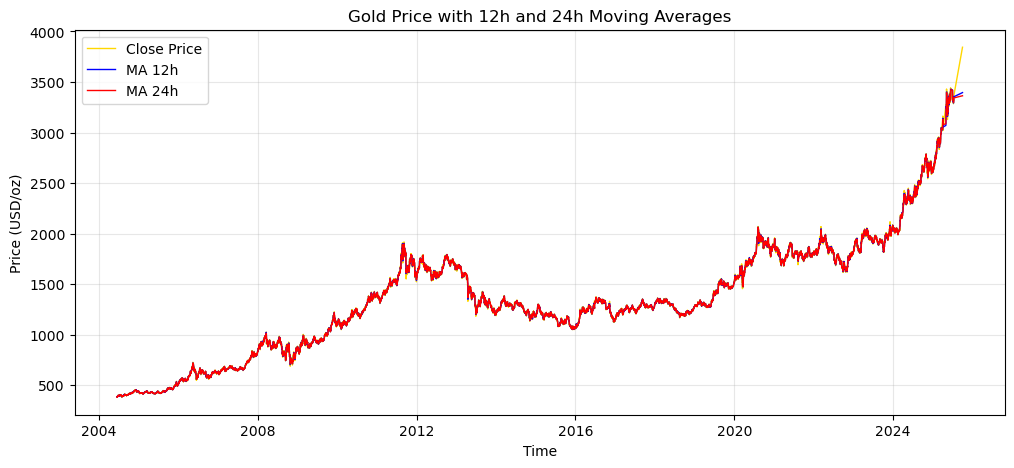

In [5]:


from pyspark.sql import Window
from pyspark.sql.functions import col, lag, avg, stddev, when

# reading stored data
raw = (spark.read.jdbc(jdbc_url, "public.raw_candles", properties=jdbc_props)
       .orderBy("ts"))

#time ordered window for rolling calculations
w = Window.orderBy("ts")

feats = (
    raw
    .withColumn("ret_1h", (col("close")/lag("close", 1).over(w) - 1))
    .withColumn("label_up", when(col("ret_1h") > 0, 1).otherwise(0))
    .withColumn("ma_12", avg("close").over(w.rowsBetween(-11, 0)))   # 12h MA
    .withColumn("ma_24", avg("close").over(w.rowsBetween(-23, 0)))   # 24h MA
    .withColumn("vol_24", stddev("close").over(w.rowsBetween(-23, 0)))
    .withColumn("momentum_12", col("close") - lag("close", 12).over(w))
    .select("ts","close","ret_1h","label_up","ma_12","ma_24","vol_24","momentum_12")
    .dropna()
)

print("Feature rows:", feats.count())
feats.orderBy("ts").show(5, truncate=False)




# gold price with 12h and 24h MA

import matplotlib.pyplot as plt

# convert spark DF to Pandas to plot
pdf_feat = feats.orderBy("ts").toPandas()

# Plot price and moving averages
plt.figure(figsize=(12,5))
plt.plot(pdf_feat["ts"], pdf_feat["close"], color="gold", label="Close Price", linewidth=1)
plt.plot(pdf_feat["ts"], pdf_feat["ma_12"], color="blue", label="MA 12h", linewidth=1)
plt.plot(pdf_feat["ts"], pdf_feat["ma_24"], color="red", label="MA 24h", linewidth=1)

plt.title("Gold Price with 12h and 24h Moving Averages")
plt.xlabel("Time")
plt.ylabel("Price (USD/oz)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



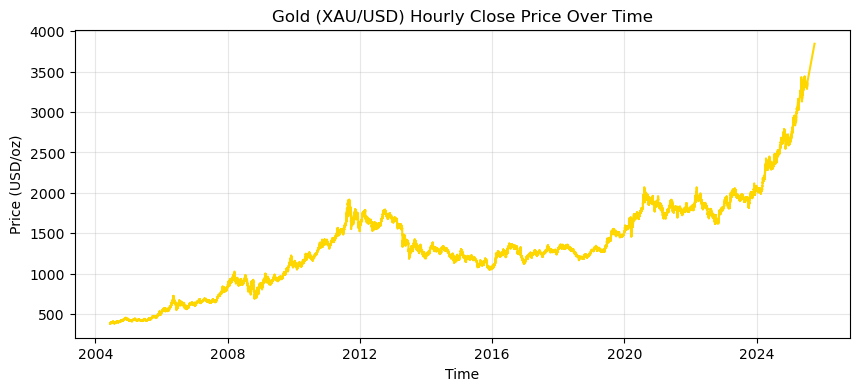

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# convert spark dataframe to pandas for plotting
pdf_prices = df.orderBy("ts").toPandas()

plt.figure(figsize=(10,4))
plt.plot(pdf_prices["ts"], pdf_prices["close"], color="gold")
plt.title("Gold (XAU/USD) Hourly Close Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price (USD/oz)")
plt.grid(True, alpha=0.3)
plt.show()


In [6]:
# save features

(feats.write
 .mode("overwrite")
 .jdbc(jdbc_url, table="public.features", properties=jdbc_props))

print("Wrote table: public.features")


Wrote table: public.features


In [7]:
#Split training and testing data

from pyspark.sql.functions import col

df_feats = (spark.read.jdbc(jdbc_url, "public.features", properties=jdbc_props)
            .orderBy("ts"))

cutoff = df_feats.selectExpr("percentile_approx(ts, 0.8) AS cut").collect()[0]["cut"]
train = df_feats.filter(col("ts") <= cutoff)
test  = df_feats.filter(col("ts") >  cutoff)

#input and target columns
feature_cols = ["ma_12","ma_24","vol_24","momentum_12"]
label_reg = "ret_1h"
label_clf = "label_up"

print("Train rows:", train.count(), "| Test rows:", test.count())


Train rows: 97441 | Test rows: 24370


In [9]:
#build feature transformation 

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)


In [10]:
# train linear regression model for next-hour return

from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(featuresCol="features", labelCol=label_reg)
pipe_lr = Pipeline(stages=[assembler, scaler, lr]).fit(train)
pred_lr = pipe_lr.transform(test)

reg_eval = RegressionEvaluator(labelCol=label_reg, predictionCol="prediction", metricName="rmse")
rmse_lr = reg_eval.evaluate(pred_lr)
print(f"RMSE (LinearRegression): {rmse_lr:.6f}")


RMSE (LinearRegression): 0.002019


In [11]:
# train random forest regression model

from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(featuresCol="features", labelCol=label_reg, numTrees=100, maxDepth=8, seed=42)
pipe_rf = Pipeline(stages=[assembler, scaler, rf]).fit(train)
pred_rf = pipe_rf.transform(test)

rmse_rf = reg_eval.evaluate(pred_rf)
print(f"RMSE (RandomForest):     {rmse_rf:.6f}")


RMSE (RandomForest):     0.002078


In [12]:
# Binary classification predict Up(1) or Down(0)

from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

train_c = train.dropna(subset=[label_clf])
test_c  = test.dropna(subset=[label_clf])

logr = LogisticRegression(featuresCol="features", labelCol=label_clf, maxIter=50)
pipe_clf = Pipeline(stages=[assembler, scaler, logr]).fit(train_c)
pred_clf = pipe_clf.transform(test_c)

auc = BinaryClassificationEvaluator(labelCol=label_clf, rawPredictionCol="rawPrediction",
                                    metricName="areaUnderROC").evaluate(pred_clf)
print(f"AUC  (LogisticRegression): {auc:.4f}")


AUC  (LogisticRegression): 0.6318


In [13]:
# apply k means clustering

from pyspark.ml.clustering import KMeans

kmeans = KMeans(featuresCol="features", k=3, seed=42)
pipe_km = Pipeline(stages=[assembler, scaler, kmeans]).fit(train)
pred_km = pipe_km.transform(test)
pred_km.groupBy("prediction").count().orderBy("prediction").show()


+----------+-----+
|prediction|count|
+----------+-----+
|         0|14156|
|         2|10214|
+----------+-----+



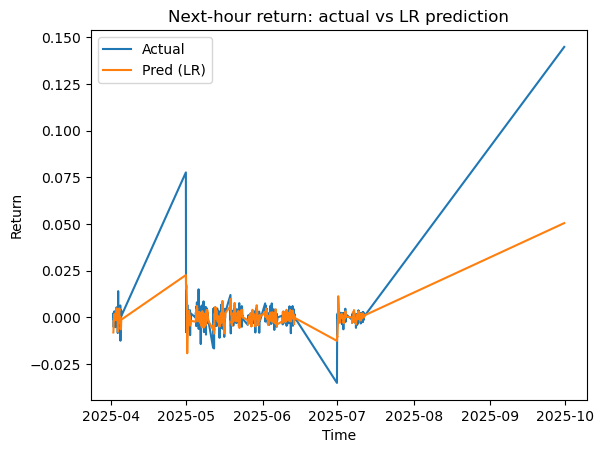

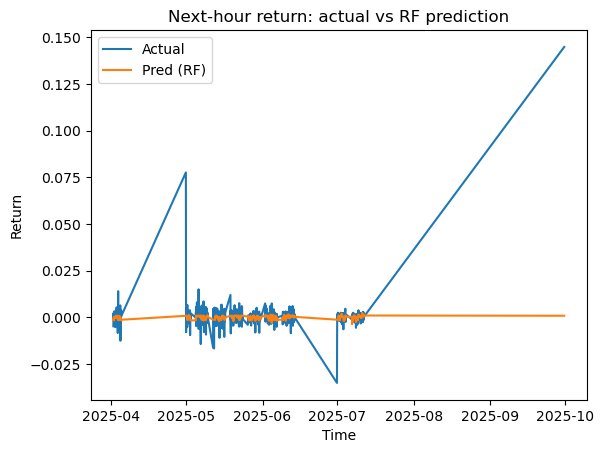

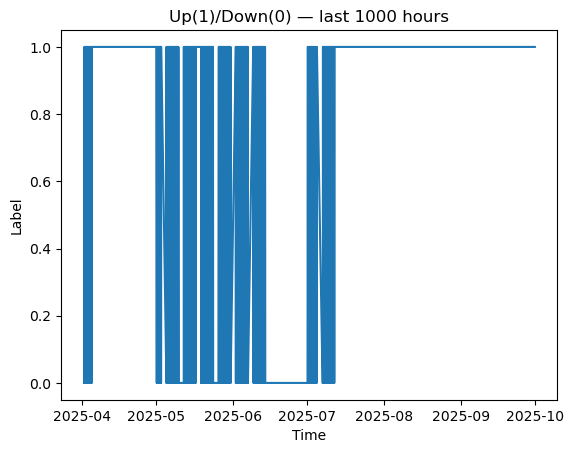

In [14]:
# plotting of the graphs

import matplotlib.pyplot as plt

pdf_lr = (pred_lr.select("ts","ret_1h","prediction")
          .orderBy("ts").toPandas().dropna().tail(1000))

plt.figure()
plt.plot(pdf_lr["ts"], pdf_lr["ret_1h"], label="Actual")
plt.plot(pdf_lr["ts"], pdf_lr["prediction"], label="Pred (LR)")
plt.legend(); plt.title("Next-hour return: actual vs LR prediction")
plt.xlabel("Time"); plt.ylabel("Return")
plt.show()

pdf_rf = (pred_rf.select("ts","ret_1h","prediction")
          .orderBy("ts").toPandas().dropna().tail(1000))

plt.figure()
plt.plot(pdf_rf["ts"], pdf_rf["ret_1h"], label="Actual")
plt.plot(pdf_rf["ts"], pdf_rf["prediction"], label="Pred (RF)")
plt.legend(); plt.title("Next-hour return: actual vs RF prediction")
plt.xlabel("Time"); plt.ylabel("Return")
plt.show()

pdf_clf = (pred_clf.select("ts","label_up")
           .orderBy("ts").toPandas().tail(1000))

plt.figure()
plt.plot(pdf_clf["ts"], pdf_clf["label_up"])
plt.title("Up(1)/Down(0) — last 1000 hours")
plt.xlabel("Time"); plt.ylabel("Label")
plt.show()
